<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/10_threshold_diagnostics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# NB10 — Limiar Causal, p95, Distribuição da `fail_rate` e Persistência Mínima

## 1. Contexto

Este notebook inicia a etapa pós-artigo do pipeline experimental da dissertação.

Os notebooks NB00 a NB09 constituem a linha histórica associada ao artigo submetido à SBPO 2026. Essa linha deve ser preservada como referência metodológica e reprodutível, sem renumeração e sem alteração retroativa dos resultados utilizados no artigo.

O NB10 tem papel de saneamento metodológico para a dissertação. Sua função é avaliar a principal vulnerabilidade identificada após a submissão do artigo: o uso de um limiar global retrospectivo, calculado sobre toda a série temporal, para definir janelas críticas e episódios críticos.

No artigo, esse limiar global foi mantido como critério experimental reprodutível e retrospectivo. Para a dissertação, entretanto, é necessário construir um cenário mais compatível com uma formulação preditiva causal, em que os parâmetros do limiar sejam estimados apenas sobre o trecho de treino ou sobre uma região histórica anterior, sendo depois aplicados ao trecho futuro.

## 2. Objetivo

O objetivo deste notebook é:

1. carregar a série temporal agregada em janelas de 5 minutos;
2. definir previamente o particionamento temporal treino/teste;
3. calcular o limiar global retrospectivo usado como referência do artigo;
4. calcular o limiar causal `train-only μ + 2σ`;
5. calcular o limiar alternativo `train-only p95`;
6. aplicar os limiares ao trecho futuro sem usar estatísticas do teste;
7. diagnosticar empiricamente a distribuição da `fail_rate`;
8. gerar histogramas com e sem zeros, com limiares marcados;
9. detectar episódios críticos sob diferentes limiares;
10. avaliar persistência mínima de 1, 2 e 3 janelas contíguas;
11. medir o impacto dos limiares e da persistência sobre janelas críticas, episódios, duração e rótulos supervisionados;
12. salvar artefatos CSV, Parquet, figuras e JSON de rastreabilidade.

## 3. Papel no Pipeline Atualizado

O NB10 não substitui o artigo e não invalida os notebooks NB00 a NB09.

Seu papel é separar claramente dois níveis de análise:

1. **linha de base retrospectiva do artigo**: limiar global calculado sobre toda a série;
2. **linha metodológica corrigida da dissertação**: limiares estimados exclusivamente no trecho de treino e aplicados ao trecho futuro.

Com isso, o pipeline passa a distinguir entre:

- o que foi usado no artigo submetido;
- o que será tratado como cenário principal ou sensibilidade essencial da dissertação;
- quais deltas precisam ser explicados no texto final.

## 4. Relação com o Artigo SBPO 2026

O artigo formulou o problema como antecipação da entrada em estado crítico em um horizonte futuro, usando séries temporais derivadas de logs, taxa de falha, episódios críticos, estados operacionais e atributos temporais causais.

Nesse contexto, a `fail_rate` foi definida como:

\[
fail\_rate_t = \frac{n\_failed_t}{n\_events_t}
\]

com a convenção:

\[
fail\_rate_t = 0, \quad \text{quando } n\_events_t = 0
\]

No artigo, uma janela foi considerada crítica quando:

\[
fail\_rate_t \geq \mu + 2\sigma
\]

onde \(\mu\) e \(\sigma\) foram estimados sobre toda a série temporal. Esse critério é útil para análise retrospectiva, mas utiliza informação do futuro quando interpretado como regra de decisão preditiva.

O NB10 mantém esse cenário global apenas como referência comparativa e introduz os cenários `train-only`, mais adequados à dissertação.

## 5. Limiar Causal e Percentil 95

A dissertação deve considerar como cenário metodologicamente mais adequado aquele em que o limiar é estimado sem acesso ao trecho futuro.

Neste notebook são avaliados três critérios principais:

| Cenário | Descrição | Papel |
|---|---|---|
| `global_m2s` | Limiar \(\mu + 2\sigma\) calculado sobre toda a série | Referência retrospectiva do artigo |
| `train_m2s` | Limiar \(\mu + 2\sigma\) calculado apenas no treino | Candidato principal da dissertação |
| `train_p95` | Percentil 95 calculado apenas no treino | Sensibilidade essencial a assimetria e caudas |

O cenário `train_m2s` corrige o uso de informação futura na estimação do limiar. O cenário `train_p95` é incluído porque a distribuição da `fail_rate` pode ser assimétrica, concentrada em zeros ou apresentar caudas pesadas, o que pode afetar a robustez da média e do desvio-padrão.

## 6. Persistência Mínima do Episódio Crítico

Este notebook também avalia o critério de persistência mínima do episódio crítico.

Esse critério define quantas janelas contíguas acima do limiar são necessárias para que uma sequência seja tratada como episódio crítico válido.

Serão avaliados:

| Persistência mínima | Interpretação |
|---|---|
| 1 janela | Comparável ao cenário do artigo |
| 2 janelas | Exige criticidade por pelo menos 10 minutos |
| 3 janelas | Exige criticidade por pelo menos 15 minutos |

O objetivo não é escolher previamente uma persistência maior, mas medir seu impacto sobre:

1. número de janelas críticas;
2. número de episódios;
3. duração média e mediana dos episódios;
4. proporção da série em estado crítico;
5. distribuição dos estados operacionais;
6. distribuição da base supervisionada de antecipação.

## 7. Estados Operacionais e Rótulo Supervisionado

Para cada cenário, os episódios críticos são usados para reconstruir os estados operacionais:

\[
S = \{NORMAL, BEFORE, DURING, AFTER\}
\]

A precedência adotada é:

\[
DURING \succ BEFORE \succ AFTER \succ NORMAL
\]

O estado `DURING` corresponde às janelas do episódio crítico. O estado `BEFORE` representa a região anterior ao episódio, definida por \(K = 24\) janelas, equivalente a 120 minutos. O estado `AFTER` representa a região posterior ao episódio, também com \(K = 24\) janelas.

A variável alvo supervisionada é definida como:

\[
y_t =
\begin{cases}
1, & \text{se existe } t' \in (t, t+H] \text{ tal que } S_{t'} = DURING \\
0, & \text{caso contrário}
\end{cases}
\]

Neste notebook, mantém-se \(H = 12\) janelas, equivalente a 60 minutos, para preservar a comparabilidade com a formulação do artigo.

## 8. Entradas Esperadas

Este notebook utiliza como entrada principal a série temporal agregada em janelas de 5 minutos, preferencialmente:

| Arquivo | Finalidade |
|---|---|
| `window_5min_series.parquet` | Série temporal contínua agregada em janelas de 5 minutos |
| `window_5min_series_scored.parquet` | Alternativa, caso a série já contenha marcações anteriores |
| `window_5min_features.parquet` | Alternativa de contingência, se contiver `fail_rate` e `bucket_id` |

A entrada mínima deve conter:

1. `bucket_id`;
2. `fail_rate`;
3. preferencialmente `n_events` e `n_failed`.

## 9. Figuras Esperadas

Ao final deste notebook, espera-se gerar:

| Figura | Arquivo |
|---|---|
| Histograma da `fail_rate` com zeros e limiares marcados | `fig_01_fail_rate_hist_all_thresholds.png` |
| Histograma da `fail_rate` sem zeros e limiares marcados | `fig_02_fail_rate_hist_nonzero_thresholds.png` |
| Série temporal da `fail_rate` com limiares e corte treino/teste | `fig_03_fail_rate_time_thresholds.png` |
| Episódios por cenário e persistência mínima | `fig_04_episodes_by_scenario_persistence.png` |
| Taxa positiva supervisionada por cenário e persistência mínima | `fig_05_positive_rate_by_scenario_persistence.png` |

## 10. Saídas Esperadas

Ao final deste notebook, espera-se obter:

| Artefato | Finalidade |
|---|---|
| `10_fail_rate_descriptive_stats.csv` | Estatísticas descritivas da `fail_rate` |
| `10_thresholds_summary.csv` | Tabela comparativa dos limiares |
| `10_episode_summary_by_scenario.csv` | Resumo de episódios por limiar e persistência |
| `10_label_impact_by_scenario.csv` | Impacto dos cenários na rotulagem supervisionada |
| `10_episodes_by_scenario.parquet` | Episódios detectados em todos os cenários |
| `10_scenario_series_states.parquet` | Série temporal rotulada por cenário |
| `10_candidate_official_series.parquet` | Série do cenário candidato para próximos notebooks |
| `10_candidate_official_episodes.parquet` | Episódios do cenário candidato para próximos notebooks |
| `10_threshold_diagnostics_summary.json` | Resumo consolidado da etapa |
| `figures_nb10_thresholds/` | Diretório com figuras do NB10 |

## 11. Observações Metodológicas

Este notebook deve ser interpretado como uma etapa de robustez metodológica.

O limiar global não é descartado, pois representa a linha histórica do artigo e permite comparação direta com os resultados já submetidos. Entretanto, para a dissertação, ele deve ser tratado como retrospectivo.

Os limiares `train-only` são metodologicamente mais adequados para uma formulação preditiva, pois nenhuma estatística do teste é usada na definição da criticidade.

A eventual mudança no número de episódios, na proporção de positivos ou nas métricas posteriores não deve ser interpretada como fracasso, mas como consequência esperada da correção metodológica.

O MD final deste notebook deverá ser escrito somente após a execução, com base nos artefatos gerados, nas tabelas, nas figuras e nos deltas observados em relação ao cenário do artigo.

Mounted at /content/drive
[Bootstrap] Atualizando repositório (git pull)...
[Bootstrap] Aviso: não foi possível atualizar via git pull: Command '['git', '-C', '/content/drive/MyDrive/Mestrado/PPCOMP_DM', 'pull']' returned non-zero exit status 1.
[Bootstrap] CWD = /content/drive/MyDrive/Mestrado/PPCOMP_DM
FEATURES_PATH = /content/drive/MyDrive/Mestrado/02-datasets/03-features
REPORTS_PATH = /content/drive/MyDrive/Mestrado/04-reports
[NB10_threshold_diagnostics] Parâmetros principais definidos.
WINDOW_MINUTES = 5
TRAIN_FRACTION = 0.8
STD_DDOF = 0
K_BEFORE_AFTER = 24
HORIZON_H = 12
PERSISTENCE_VALUES = [1, 2, 3]
CANDIDATE_THRESHOLD_SCENARIO = train_m2s
CANDIDATE_PERSISTENCE_MIN_WINDOWS = 1
[NB10_threshold_diagnostics] Arquivo encontrado, mas sem fail_rate: /content/drive/MyDrive/Mestrado/02-datasets/03-features/window_5min_series.parquet
[NB10_threshold_diagnostics] Série temporal carregada: /content/drive/MyDrive/Mestrado/02-datasets/03-features/window_5min_series_scored.parquet
[NB10_th

,bucket_id,bucket_start_us,n_events,n_failed,n_machines,n_collections,mean_priority,mean_req_cpus,mean_req_mem,req_cpus_presence_rate,...,event_FAIL_count,event_SCHEDULE_count,event_FINISH_count,event_ENABLE_count,event_LOST_count,event_EVICT_count,event_KILL_count,fail_rate,is_critical,row_position
0,0,0,56452,37082,43394,1232,166.682739,0.018434,0.009607,0.986289,...,37082,154,600,18616,0,0,0,0.656877,1,0
1,1,300000000,0,0,0,0,NaN,NaN,NaN,0.000000,...,0,0,0,0,0,0,0,0.000000,0,1
2,2,600000000,28,9,28,19,208.464286,0.008100,0.016303,1.000000,...,9,0,7,7,5,0,0,0.321429,0,2
3,3,900000000,32,2,32,18,135.656250,0.009495,0.003928,1.000000,...,2,0,19,4,6,0,1,0.062500,0,3
4,4,1200000000,29,6,28,20,233.068966,0.012932,0.003717,1.000000,...,6,0,6,6,11,0,0,0.206897,0,4



=== Colunas disponíveis ===


,columns
0,bucket_id
1,bucket_start_us
2,n_events
3,n_failed
4,n_machines
5,n_collections
6,mean_priority
7,mean_req_cpus
8,mean_req_mem
9,req_cpus_presence_rate


[NB10_threshold_diagnostics] Split temporal definido antes da estimação dos limiares oficiais.
n_rows = 8930
train_rows = 7144
test_rows = 1786
train_last_bucket = 7143
test_first_bucket = 7144

=== Distribuição treino/teste ===


...


=== Estatísticas descritivas da fail_rate ===


,scope,count,zero_count,zero_rate,nonzero_count,mean,std,min,p01,p05,p25,median,p75,p90,p95,p99,max
0,full_series,8930,499,0.055879,8431,0.196580,0.140911,0.000000,0.000000,0.000000,0.093750,0.171875,0.272727,0.380952,0.461538,0.636364,1.000000
1,train_only,7144,378,0.052912,6766,0.181582,0.126378,0.000000,0.000000,0.000000,0.090909,0.160000,0.250000,0.347826,0.411765,0.567328,0.887892
2,test_only,1786,121,0.067749,1665,0.256568,0.175770,0.000000,0.000000,0.000000,0.117647,0.238095,0.357143,0.500000,0.575568,0.755286,1.000000
3,full_series_nonzero,8431,0,0.000000,8431,0.208214,0.136413,0.000144,0.014555,0.041667,0.107143,0.181818,0.283559,0.388889,0.466667,0.640000,1.000000
4,train_only_nonzero,6766,0,0.000000,6766,0.191727,0.122142,0.000144,0.014456,0.040000,0.100000,0.166667,0.259259,0.352941,0.416667,0.571429,0.887892
5,test_only_nonzero,1665,0,0.000000,1665,0.275213,0.167359,0.001041,0.016563,0.052632,0.142857,0.250000,0.375000,0.500000,0.580306,0.769412,1.000000


[NB10_threshold_diagnostics] Estatísticas descritivas salvas: /content/drive/MyDrive/Mestrado/04-reports/10_fail_rate_descriptive_stats.csv

=== Limires avaliados ===


,scenario,description,fit_scope,uses_test_statistics,mu,std,p95,threshold_value,role
0,global_m2s,Limiar global retrospectivo μ + 2σ calculado s...,full_series,True,0.196580,0.140911,0.461538,0.478401,baseline_retrospective_article
1,train_m2s,Limiar causal μ + 2σ calculado apenas no treino,train_only,False,0.181582,0.126378,0.411765,0.434338,candidate_main_dissertation
2,train_p95,Limiar causal percentil 95 calculado apenas no...,train_only,False,0.181582,0.126378,0.411765,0.411765,essential_sensitivity_dissertation


[NB10_threshold_diagnostics] Tabela de limiares salva: /content/drive/MyDrive/Mestrado/04-reports/10_thresholds_summary.csv


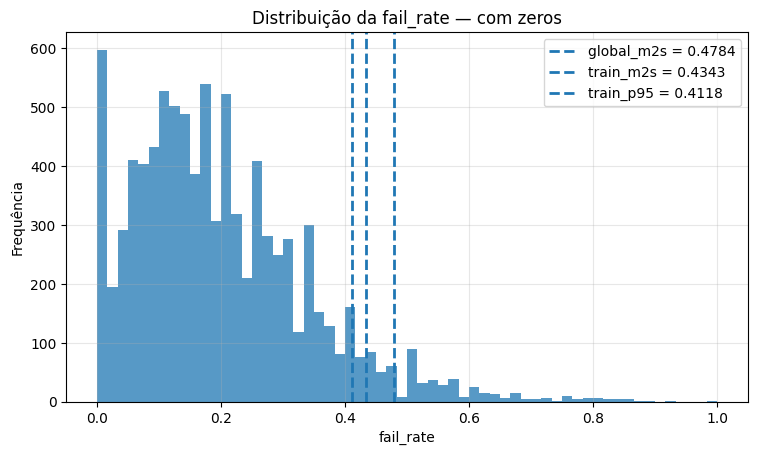

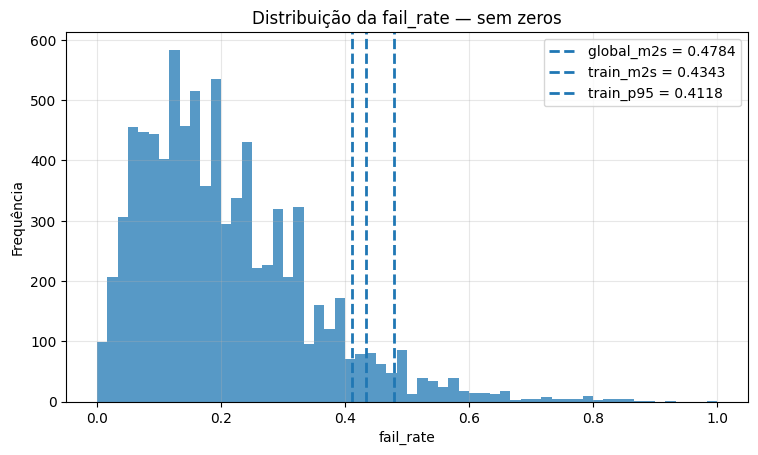

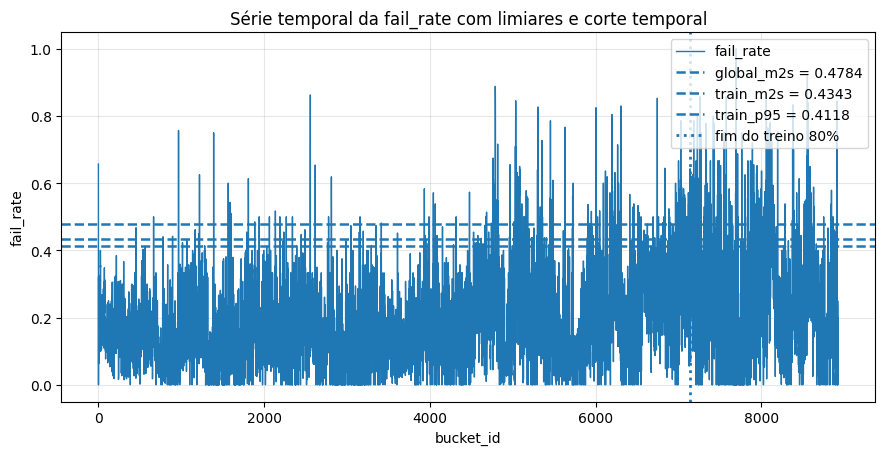


=== Resumo de episódios por cenário ===


,scenario,threshold_value,persistence_min_windows,total_windows,critical_windows,critical_window_rate,episode_count,episode_duration_mean_windows,episode_duration_median_windows,episode_duration_min_windows,episode_duration_max_windows,one_window_episodes,normal_windows,before_windows,during_windows,after_windows
0,global_m2s,0.478401,1,8930,390,0.043673,285,1.368421,1.0,1,7,227,4279,2966,390,1295
1,global_m2s,0.478401,2,8930,163,0.018253,58,2.810345,2.0,2,7,0,7236,960,163,571
2,global_m2s,0.478401,3,8930,99,0.011086,26,3.807692,3.0,3,7,0,7943,486,99,402
3,train_m2s,0.434338,1,8930,562,0.062934,388,1.448454,1.0,1,18,300,3187,3767,562,1414
4,train_m2s,0.434338,2,8930,262,0.029339,88,2.977273,2.0,2,18,0,6543,1345,262,780
5,train_m2s,0.434338,3,8930,156,0.017469,35,4.457143,4.0,3,18,0,7651,628,156,495
6,train_p95,0.411765,1,8930,685,0.076708,471,1.454352,1.0,1,18,359,2653,4213,685,1379
7,train_p95,0.411765,2,8930,326,0.036506,112,2.910714,2.0,2,18,0,6172,1631,326,801
8,train_p95,0.411765,3,8930,190,0.021277,44,4.318182,4.0,3,18,0,7473,729,190,538



=== Impacto na base supervisionada por cenário ===


,scenario,threshold_value,persistence_min_windows,total_windows,supervised_rows,positives,negatives,positive_rate,eligible_before_rows,eligible_before_y1,eligible_before_y0,eligible_normal_rows,eligible_normal_y1,eligible_normal_y0,excluded_due_to_during_after,excluded_due_to_incomplete_horizon
0,global_m2s,0.478401,1,8930,7245,1987,5258,0.274258,2966,1987,979,4279,0,4279,1685,12
1,global_m2s,0.478401,2,8930,8196,549,7647,0.066984,960,549,411,7236,0,7236,734,12
2,global_m2s,0.478401,3,8930,8417,268,8149,0.031840,486,268,218,7931,0,7931,501,12
3,train_m2s,0.434338,1,8930,6954,2605,4349,0.374605,3767,2605,1162,3187,0,3187,1976,12
4,train_m2s,0.434338,2,8930,7888,798,7090,0.101166,1345,798,547,6543,0,6543,1042,12
5,train_m2s,0.434338,3,8930,8267,342,7925,0.041369,628,342,286,7639,0,7639,651,12
6,train_p95,0.411765,1,8930,6866,2987,3879,0.435042,4213,2987,1226,2653,0,2653,2064,12
7,train_p95,0.411765,2,8930,7803,989,6814,0.126746,1631,989,642,6172,0,6172,1127,12
8,train_p95,0.411765,3,8930,8190,415,7775,0.050672,729,415,314,7461,0,7461,728,12



=== Amostra de episódios detectados ===


,scenario,threshold_value,persistence_min_windows,episode_id,start_index,end_index,start_bucket,end_bucket,duration_windows,duration_minutes,episode_partition
0,global_m2s,0.478401,1,1,0,0,0,0,1,5,train
1,global_m2s,0.478401,1,2,666,666,666,666,1,5,train
2,global_m2s,0.478401,1,3,967,967,967,967,1,5,train
3,global_m2s,0.478401,1,4,1220,1220,1220,1220,1,5,train
4,global_m2s,0.478401,1,5,1391,1391,1391,1391,1,5,train


[NB10_threshold_diagnostics] Resumo de episódios salvo: /content/drive/MyDrive/Mestrado/04-reports/10_episode_summary_by_scenario.csv
[NB10_threshold_diagnostics] Impacto na rotulagem salvo: /content/drive/MyDrive/Mestrado/04-reports/10_label_impact_by_scenario.csv
[NB10_threshold_diagnostics] Episódios por cenário salvos: /content/drive/MyDrive/Mestrado/04-reports/10_episodes_by_scenario.parquet
[NB10_threshold_diagnostics] Série rotulada por cenário salva: /content/drive/MyDrive/Mestrado/04-reports/10_scenario_series_states.parquet


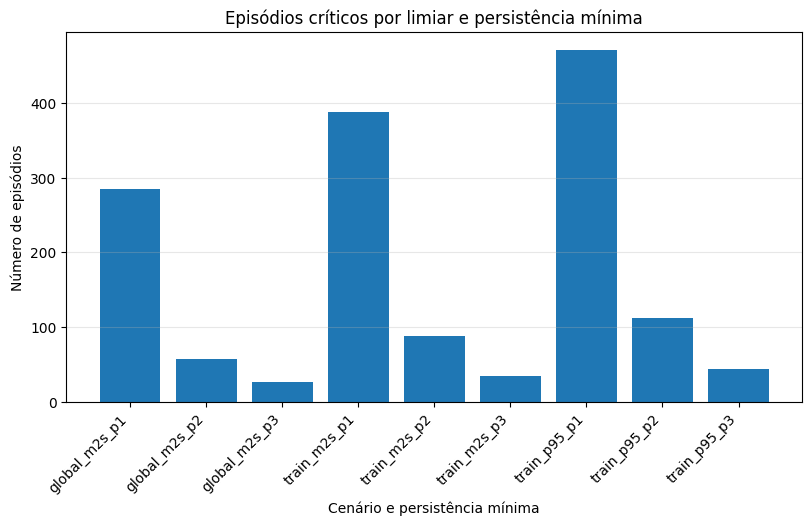

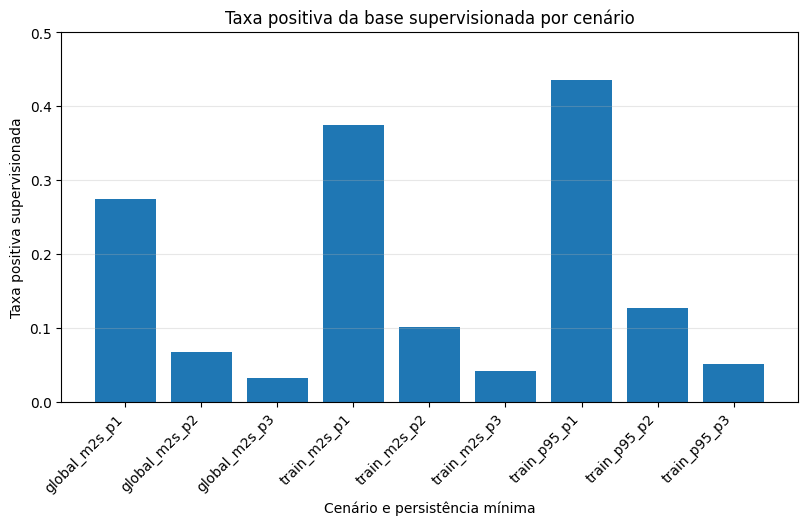


=== Cenário candidato salvo para próximos notebooks ===


,notebook,candidate_threshold_scenario,candidate_persistence_min_windows,candidate_series_file,candidate_episodes_file,interpretation,no_test_statistics_used_for_threshold,train_fraction,train_rows,test_rows,train_last_bucket,test_first_bucket,k_before_after,horizon_h
0,NB10,train_m2s,1,/content/drive/MyDrive/Mestrado/04-reports/10_...,/content/drive/MyDrive/Mestrado/04-reports/10_...,Cenário candidato para uso nos próximos notebo...,True,0.8,7144,1786,7143,7144,24,12


[NB10_threshold_diagnostics] Série candidata salva: /content/drive/MyDrive/Mestrado/04-reports/10_candidate_official_series.parquet
[NB10_threshold_diagnostics] Episódios candidatos salvos: /content/drive/MyDrive/Mestrado/04-reports/10_candidate_official_episodes.parquet
[NB10_threshold_diagnostics] Metadados do cenário candidato salvos: /content/drive/MyDrive/Mestrado/04-reports/10_candidate_official_metadata.json
[NB10_threshold_diagnostics] Summary consolidado salvo: /content/drive/MyDrive/Mestrado/04-reports/10_threshold_diagnostics_summary.json

=== Arquivos gerados pelo NB10 ===


,artifact,path,exists
0,10_fail_rate_descriptive_stats.csv,/content/drive/MyDrive/Mestrado/04-reports/10_...,True
1,10_thresholds_summary.csv,/content/drive/MyDrive/Mestrado/04-reports/10_...,True
2,10_episode_summary_by_scenario.csv,/content/drive/MyDrive/Mestrado/04-reports/10_...,True
3,10_label_impact_by_scenario.csv,/content/drive/MyDrive/Mestrado/04-reports/10_...,True
4,10_episodes_by_scenario.parquet,/content/drive/MyDrive/Mestrado/04-reports/10_...,True
5,10_scenario_series_states.parquet,/content/drive/MyDrive/Mestrado/04-reports/10_...,True
6,10_candidate_official_series.parquet,/content/drive/MyDrive/Mestrado/04-reports/10_...,True
7,10_candidate_official_episodes.parquet,/content/drive/MyDrive/Mestrado/04-reports/10_...,True
8,10_candidate_official_metadata.json,/content/drive/MyDrive/Mestrado/04-reports/10_...,True
9,10_threshold_diagnostics_summary.json,/content/drive/MyDrive/Mestrado/04-reports/10_...,True



=== Figuras geradas ===


,figure,repo_path,reports_path
0,fig_01_fail_rate_hist_all_thresholds,/content/drive/MyDrive/Mestrado/PPCOMP_DM/figu...,/content/drive/MyDrive/Mestrado/04-reports/fig...
1,fig_02_fail_rate_hist_nonzero_thresholds,/content/drive/MyDrive/Mestrado/PPCOMP_DM/figu...,/content/drive/MyDrive/Mestrado/04-reports/fig...
2,fig_03_fail_rate_time_thresholds,/content/drive/MyDrive/Mestrado/PPCOMP_DM/figu...,/content/drive/MyDrive/Mestrado/04-reports/fig...
3,fig_04_episodes_by_scenario_persistence,/content/drive/MyDrive/Mestrado/PPCOMP_DM/figu...,/content/drive/MyDrive/Mestrado/04-reports/fig...
4,fig_05_positive_rate_by_scenario_persistence,/content/drive/MyDrive/Mestrado/PPCOMP_DM/figu...,/content/drive/MyDrive/Mestrado/04-reports/fig...



=== Leitura metodológica preliminar ===
O NB10 foi executado como diagnóstico metodológico. O limiar global permanece como referência retrospectiva do artigo; os limiares train-only representam a correção causal esperada para a dissertação. A escolha final da persistência mínima deve ser feita após análise do impacto em episódios, estados e distribuição supervisionada.


In [1]:
# ============================================================
# NB10 — Limiar Causal, p95, Distribuição da fail_rate
# e Persistência Mínima
# Pipeline PPCOMP_DM
#
# Escopo:
# - Preservar NB00–NB09 como linha histórica do artigo
# - Carregar a série temporal agregada em janelas de 5 minutos
# - Definir split temporal antes da estimação dos limiares oficiais
# - Calcular limiar global retrospectivo como referência do artigo
# - Calcular limiar train-only μ + 2σ
# - Calcular limiar train-only p95
# - Aplicar limiares ao trecho futuro sem usar estatísticas do teste
# - Gerar histogramas da fail_rate com zeros e sem zeros
# - Detectar episódios por cenário e persistência mínima
# - Reconstruir estados NORMAL/BEFORE/DURING/AFTER
# - Construir alvo supervisionado y_t para impacto nos rótulos
# - Salvar CSV, Parquet, figuras e summary JSON
#
# Importante:
# - O limiar global é referência retrospectiva, não cenário oficial causal
# - Os cenários train-only não usam dados do teste na estimação do limiar
# - Persistência mínima é avaliada, não decidida previamente
# - O cenário candidato salvo para NB11 pode ser ajustado após análise
# ============================================================

from pathlib import Path
import os
import sys
import subprocess
import importlib
import random
import json
import warnings

import numpy as np
import pandas as pd

from IPython.display import display
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ─────────────────────────────────────────────────────────────
# BLOCO 0 — Bootstrap
# ─────────────────────────────────────────────────────────────

if not Path("/content/drive/MyDrive").exists():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:
        print("[Bootstrap] Aviso: não foi possível montar o Google Drive automaticamente.")
        print("[Bootstrap] Detalhe:", e)
else:
    print("[Bootstrap] Google Drive já montado.")

REPO_DIR = Path("/content/drive/MyDrive/Mestrado/PPCOMP_DM")
GITHUB_REPO = "https://github.com/sergiocostaifes/PPCOMP_DM.git"

if not REPO_DIR.exists():
    REPO_DIR.parent.mkdir(parents=True, exist_ok=True)
    print(f"[Bootstrap] Clonando repositório em: {REPO_DIR}")
    subprocess.run(["git", "clone", GITHUB_REPO, str(REPO_DIR)], check=True)
else:
    try:
        print("[Bootstrap] Atualizando repositório (git pull)...")
        subprocess.run(["git", "-C", str(REPO_DIR), "pull"], check=True)
    except Exception as e:
        print("[Bootstrap] Aviso: não foi possível atualizar via git pull:", e)

os.chdir(str(REPO_DIR))
print("[Bootstrap] CWD =", os.getcwd())

repo_str = str(REPO_DIR)
if repo_str not in sys.path:
    sys.path.insert(0, repo_str)

importlib.invalidate_caches()

try:
    from src.paths import FEATURES_PATH, REPORTS_PATH, ensure_dirs
    ensure_dirs()
except Exception as e:
    print("[Bootstrap] Aviso: não foi possível importar src.paths.")
    print("[Bootstrap] Tentando usar caminhos padrão no Google Drive.")
    print("[Bootstrap] Detalhe:", e)

    FEATURES_PATH = Path("/content/drive/MyDrive/Mestrado/02-datasets/03-features")
    REPORTS_PATH = Path("/content/drive/MyDrive/Mestrado/04-reports")
    FEATURES_PATH.mkdir(parents=True, exist_ok=True)
    REPORTS_PATH.mkdir(parents=True, exist_ok=True)

print("FEATURES_PATH =", FEATURES_PATH)
print("REPORTS_PATH =", REPORTS_PATH)


def log(msg: str) -> None:
    """Imprime mensagens padronizadas desta etapa do pipeline."""
    print(f"[NB10_threshold_diagnostics] {msg}")


# ─────────────────────────────────────────────────────────────
# BLOCO 1 — Parâmetros do notebook
# ─────────────────────────────────────────────────────────────

WINDOW_MINUTES = 5
TRAIN_FRACTION = 0.80
STD_DDOF = 0

K_BEFORE_AFTER = 24
HORIZON_H = 12

PERSISTENCE_VALUES = [1, 2, 3]

# Cenário candidato para alimentar NB11.
# Mantém a correção causal do limiar, mas preserva persistência mínima = 1
# como ponte conservadora com o artigo. Essa escolha pode ser revista após
# a análise dos resultados do NB10.
CANDIDATE_THRESHOLD_SCENARIO = "train_m2s"
CANDIDATE_PERSISTENCE_MIN_WINDOWS = 1

FIG_DIR = REPO_DIR / "figures_nb10_thresholds"
FIG_DIR.mkdir(parents=True, exist_ok=True)

REPORT_FIG_DIR = REPORTS_PATH / "figures_nb10_thresholds"
REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)

FAIL_RATE_STATS_FILE = REPORTS_PATH / "10_fail_rate_descriptive_stats.csv"
THRESHOLDS_SUMMARY_FILE = REPORTS_PATH / "10_thresholds_summary.csv"
EPISODE_SUMMARY_FILE = REPORTS_PATH / "10_episode_summary_by_scenario.csv"
LABEL_IMPACT_FILE = REPORTS_PATH / "10_label_impact_by_scenario.csv"

EPISODES_ALL_FILE = REPORTS_PATH / "10_episodes_by_scenario.parquet"
SCENARIO_SERIES_FILE = REPORTS_PATH / "10_scenario_series_states.parquet"

CANDIDATE_SERIES_FILE = REPORTS_PATH / "10_candidate_official_series.parquet"
CANDIDATE_EPISODES_FILE = REPORTS_PATH / "10_candidate_official_episodes.parquet"
CANDIDATE_METADATA_FILE = REPORTS_PATH / "10_candidate_official_metadata.json"

SUMMARY_FILE = REPORTS_PATH / "10_threshold_diagnostics_summary.json"

# Candidatos de entrada. O primeiro existente com fail_rate será usado.
INPUT_CANDIDATES = [
    FEATURES_PATH / "window_5min_series.parquet",
    FEATURES_PATH / "window_5min_series_scored.parquet",
    FEATURES_PATH / "window_5min_features.parquet",
    FEATURES_PATH / "window_5min_labeled.parquet",
]

log("Parâmetros principais definidos.")
print("WINDOW_MINUTES =", WINDOW_MINUTES)
print("TRAIN_FRACTION =", TRAIN_FRACTION)
print("STD_DDOF =", STD_DDOF)
print("K_BEFORE_AFTER =", K_BEFORE_AFTER)
print("HORIZON_H =", HORIZON_H)
print("PERSISTENCE_VALUES =", PERSISTENCE_VALUES)
print("CANDIDATE_THRESHOLD_SCENARIO =", CANDIDATE_THRESHOLD_SCENARIO)
print("CANDIDATE_PERSISTENCE_MIN_WINDOWS =", CANDIDATE_PERSISTENCE_MIN_WINDOWS)


# ─────────────────────────────────────────────────────────────
# BLOCO 2 — Funções auxiliares
# ─────────────────────────────────────────────────────────────

def find_input_series(candidates):
    """
    Seleciona o primeiro arquivo Parquet existente que contenha
    as colunas mínimas para o NB10.
    """
    checked = []
    for path in candidates:
        checked.append(str(path))
        if not path.exists():
            continue

        df = pd.read_parquet(path)
        if "fail_rate" not in df.columns:
            log(f"Arquivo encontrado, mas sem fail_rate: {path}")
            continue

        if "bucket_id" not in df.columns:
            log(f"Arquivo encontrado, mas sem bucket_id: {path}")
            continue

        return path, df

    raise FileNotFoundError(
        "Nenhum arquivo de entrada adequado foi encontrado. "
        "Arquivos verificados:\n" + "\n".join(checked)
    )


def as_float(x):
    """Converte valores NumPy/Pandas para float nativo com tratamento de NaN."""
    if pd.isna(x):
        return None
    return float(x)


def as_int(x):
    """Converte valores NumPy/Pandas para int nativo com tratamento de NaN."""
    if pd.isna(x):
        return None
    return int(x)


def save_current_figure(filename: str) -> dict:
    """Salva a figura atual no repositório e em REPORTS_PATH."""
    out_repo = FIG_DIR / filename
    out_reports = REPORT_FIG_DIR / filename

    plt.savefig(out_repo, dpi=300, bbox_inches="tight")
    plt.savefig(out_reports, dpi=300, bbox_inches="tight")

    return {
        "repo_path": str(out_repo),
        "reports_path": str(out_reports),
    }


def format_float(x, digits=6):
    """Formata valores numéricos para tabelas/legendas."""
    if x is None or pd.isna(x):
        return "NA"
    return f"{x:.{digits}f}"


def detect_episodes_from_flag(
    df: pd.DataFrame,
    flag_col: str,
    scenario: str,
    threshold_value: float,
    persistence_min_windows: int,
    split_train_last_position: int,
) -> pd.DataFrame:
    """
    Detecta episódios como sequências máximas de janelas críticas contíguas.

    A persistência mínima é aplicada sobre a sequência original de janelas
    acima do limiar. Sequências com duração menor que persistence_min_windows
    são descartadas. Sequências válidas mantêm todas as janelas do trecho como DURING.
    """
    flags = df[flag_col].fillna(False).astype(bool).to_numpy()
    bucket_ids = df["bucket_id"].to_numpy()

    rows = []
    in_run = False
    start_idx = None

    def close_run(end_idx):
        duration = end_idx - start_idx + 1

        if duration < persistence_min_windows:
            return

        start_bucket = int(bucket_ids[start_idx])
        end_bucket = int(bucket_ids[end_idx])

        if end_idx <= split_train_last_position:
            partition = "train"
        elif start_idx > split_train_last_position:
            partition = "test"
        else:
            partition = "cross_split"

        rows.append({
            "scenario": scenario,
            "threshold_value": float(threshold_value),
            "persistence_min_windows": int(persistence_min_windows),
            "episode_id": len(rows) + 1,
            "start_index": int(start_idx),
            "end_index": int(end_idx),
            "start_bucket": start_bucket,
            "end_bucket": end_bucket,
            "duration_windows": int(duration),
            "duration_minutes": int(duration * WINDOW_MINUTES),
            "episode_partition": partition,
        })

    for i, is_crit in enumerate(flags):
        if is_crit and not in_run:
            in_run = True
            start_idx = i
        elif not is_crit and in_run:
            close_run(i - 1)
            in_run = False
            start_idx = None

    if in_run:
        close_run(len(flags) - 1)

    return pd.DataFrame(rows)


def build_valid_critical_flag(
    n_rows: int,
    episodes_df: pd.DataFrame,
) -> np.ndarray:
    """Reconstrói o vetor booleano de janelas críticas válidas a partir dos episódios."""
    flag = np.zeros(n_rows, dtype=bool)

    if episodes_df.empty:
        return flag

    for _, ep in episodes_df.iterrows():
        s = int(ep["start_index"])
        e = int(ep["end_index"])
        flag[s:e + 1] = True

    return flag


def assign_states_from_episodes(
    base_df: pd.DataFrame,
    episodes_df: pd.DataFrame,
    k_before_after: int,
) -> pd.DataFrame:
    """
    Atribui estados NORMAL/BEFORE/DURING/AFTER a partir dos episódios.

    Precedência:
    DURING > BEFORE > AFTER > NORMAL
    """
    n = len(base_df)

    during = np.zeros(n, dtype=bool)
    before = np.zeros(n, dtype=bool)
    after = np.zeros(n, dtype=bool)

    if not episodes_df.empty:
        for _, ep in episodes_df.iterrows():
            s = int(ep["start_index"])
            e = int(ep["end_index"])

            during[s:e + 1] = True

            b0 = max(0, s - k_before_after)
            b1 = max(0, s - 1)
            if b0 <= b1:
                before[b0:b1 + 1] = True

            a0 = min(n - 1, e + 1)
            a1 = min(n - 1, e + k_before_after)
            if a0 <= a1:
                after[a0:a1 + 1] = True

    state = np.full(n, "NORMAL", dtype=object)
    state[after] = "AFTER"
    state[before] = "BEFORE"
    state[during] = "DURING"

    out = base_df.copy()
    out["state"] = state
    out["is_during"] = during
    out["is_before"] = state == "BEFORE"
    out["is_after"] = state == "AFTER"
    out["is_normal"] = state == "NORMAL"

    return out


def build_supervised_target(
    state_df: pd.DataFrame,
    horizon_h: int,
) -> pd.DataFrame:
    """
    Constrói y_t = 1 se existe DURING em (t, t+H].

    A base supervisionada é elegível apenas para estados NORMAL/BEFORE
    e para janelas com horizonte futuro completo.
    """
    out = state_df.copy()
    n = len(out)

    during = out["is_during"].astype(bool).to_numpy()
    y = np.zeros(n, dtype=int)
    horizon_complete = np.zeros(n, dtype=bool)

    for i in range(n):
        if i + horizon_h < n:
            horizon_complete[i] = True
            y[i] = int(during[i + 1:i + horizon_h + 1].any())

    eligible_state = out["state"].isin(["NORMAL", "BEFORE"]).to_numpy()
    eligible_supervised = eligible_state & horizon_complete

    out["horizon_complete"] = horizon_complete
    out["eligible_supervised"] = eligible_supervised
    out["y"] = y

    return out


def summarize_scenario(
    scenario: str,
    threshold_value: float,
    persistence_min_windows: int,
    scenario_df: pd.DataFrame,
    episodes_df: pd.DataFrame,
) -> dict:
    """Gera resumo de episódios e distribuição de estados por cenário."""
    n = len(scenario_df)
    critical_windows = int(scenario_df["is_critical"].sum())

    if episodes_df.empty:
        episode_count = 0
        duration_mean = np.nan
        duration_median = np.nan
        duration_min = np.nan
        duration_max = np.nan
        one_window_episodes = 0
    else:
        episode_count = int(len(episodes_df))
        duration_mean = float(episodes_df["duration_windows"].mean())
        duration_median = float(episodes_df["duration_windows"].median())
        duration_min = int(episodes_df["duration_windows"].min())
        duration_max = int(episodes_df["duration_windows"].max())
        one_window_episodes = int((episodes_df["duration_windows"] == 1).sum())

    state_counts = (
        scenario_df["state"]
        .value_counts()
        .reindex(["NORMAL", "BEFORE", "DURING", "AFTER"], fill_value=0)
    )

    return {
        "scenario": scenario,
        "threshold_value": float(threshold_value),
        "persistence_min_windows": int(persistence_min_windows),
        "total_windows": int(n),
        "critical_windows": critical_windows,
        "critical_window_rate": float(critical_windows / n) if n else np.nan,
        "episode_count": episode_count,
        "episode_duration_mean_windows": duration_mean,
        "episode_duration_median_windows": duration_median,
        "episode_duration_min_windows": duration_min,
        "episode_duration_max_windows": duration_max,
        "one_window_episodes": one_window_episodes,
        "normal_windows": int(state_counts["NORMAL"]),
        "before_windows": int(state_counts["BEFORE"]),
        "during_windows": int(state_counts["DURING"]),
        "after_windows": int(state_counts["AFTER"]),
    }


def summarize_label_impact(
    scenario: str,
    threshold_value: float,
    persistence_min_windows: int,
    scenario_df: pd.DataFrame,
) -> dict:
    """Resume o impacto do cenário na base supervisionada de antecipação."""
    eligible = scenario_df[scenario_df["eligible_supervised"]].copy()

    total_windows = len(scenario_df)
    supervised_rows = len(eligible)
    positives = int(eligible["y"].sum()) if supervised_rows > 0 else 0
    negatives = int(supervised_rows - positives)

    before_rows = eligible[eligible["state"] == "BEFORE"].copy()
    normal_rows = eligible[eligible["state"] == "NORMAL"].copy()

    before_y1 = int(before_rows["y"].sum()) if len(before_rows) else 0
    before_y0 = int(len(before_rows) - before_y1)

    normal_y1 = int(normal_rows["y"].sum()) if len(normal_rows) else 0
    normal_y0 = int(len(normal_rows) - normal_y1)

    return {
        "scenario": scenario,
        "threshold_value": float(threshold_value),
        "persistence_min_windows": int(persistence_min_windows),
        "total_windows": int(total_windows),
        "supervised_rows": int(supervised_rows),
        "positives": int(positives),
        "negatives": int(negatives),
        "positive_rate": float(positives / supervised_rows) if supervised_rows else np.nan,
        "eligible_before_rows": int(len(before_rows)),
        "eligible_before_y1": int(before_y1),
        "eligible_before_y0": int(before_y0),
        "eligible_normal_rows": int(len(normal_rows)),
        "eligible_normal_y1": int(normal_y1),
        "eligible_normal_y0": int(normal_y0),
        "excluded_due_to_during_after": int(
            scenario_df["state"].isin(["DURING", "AFTER"]).sum()
        ),
        "excluded_due_to_incomplete_horizon": int(
            (~scenario_df["horizon_complete"]).sum()
        ),
    }


# ─────────────────────────────────────────────────────────────
# BLOCO 3 — Leitura e validação da série temporal
# ─────────────────────────────────────────────────────────────

input_file, df_series_raw = find_input_series(INPUT_CANDIDATES)

df_series = df_series_raw.copy()

# Mantém apenas uma linha por bucket_id, se houver duplicidade acidental.
df_series = (
    df_series
    .sort_values("bucket_id")
    .drop_duplicates(subset=["bucket_id"], keep="first")
    .reset_index(drop=True)
)

df_series["bucket_id"] = df_series["bucket_id"].astype(int)
df_series["fail_rate"] = df_series["fail_rate"].astype(float)

if "n_events" not in df_series.columns:
    df_series["n_events"] = np.nan

if "n_failed" not in df_series.columns:
    df_series["n_failed"] = np.nan

df_series["row_position"] = np.arange(len(df_series), dtype=int)

required_cols = {"bucket_id", "fail_rate", "row_position"}
missing_cols = required_cols - set(df_series.columns)
assert not missing_cols, f"Colunas obrigatórias ausentes: {missing_cols}"

assert df_series["fail_rate"].notna().all(), "Há valores ausentes em fail_rate."
assert (df_series["fail_rate"] >= 0).all(), "Há valores negativos em fail_rate."

log(f"Série temporal carregada: {input_file}")
log(f"Shape da série: {df_series.shape}")
log(f"bucket_id mínimo={df_series['bucket_id'].min()} | máximo={df_series['bucket_id'].max()}")

print("\n=== Head da série temporal ===")
display(df_series.head())

print("\n=== Colunas disponíveis ===")
display(pd.DataFrame({"columns": list(df_series.columns)}))


# ─────────────────────────────────────────────────────────────
# BLOCO 4 — Split temporal treino/teste antes dos limiares oficiais
# ─────────────────────────────────────────────────────────────

n_rows = len(df_series)
assert n_rows > 0, "Série temporal vazia."

train_rows = int(np.floor(n_rows * TRAIN_FRACTION))
test_rows = n_rows - train_rows

assert train_rows > 0, "Trecho de treino vazio."
assert test_rows > 0, "Trecho de teste vazio."

split_train_last_position = train_rows - 1
split_test_first_position = train_rows

train_last_bucket = int(df_series.loc[split_train_last_position, "bucket_id"])
test_first_bucket = int(df_series.loc[split_test_first_position, "bucket_id"])

df_series["temporal_partition"] = np.where(
    df_series["row_position"] <= split_train_last_position,
    "train",
    "test",
)

train_mask = df_series["temporal_partition"] == "train"
test_mask = df_series["temporal_partition"] == "test"

log("Split temporal definido antes da estimação dos limiares oficiais.")
print("n_rows =", n_rows)
print("train_rows =", train_rows)
print("test_rows =", test_rows)
print("train_last_bucket =", train_last_bucket)
print("test_first_bucket =", test_first_bucket)

print("\n=== Distribuição treino/teste ===")
display(df_series["temporal_partition"].value_counts().to_frame("count"))


# ─────────────────────────────────────────────────────────────
# BLOCO 5 — Estatísticas descritivas da fail_rate
# ─────────────────────────────────────────────────────────────

def descriptive_stats(values: pd.Series, scope: str) -> dict:
    """Calcula estatísticas descritivas da fail_rate."""
    values = values.dropna().astype(float)

    return {
        "scope": scope,
        "count": int(values.shape[0]),
        "zero_count": int((values == 0).sum()),
        "zero_rate": float((values == 0).mean()) if len(values) else np.nan,
        "nonzero_count": int((values > 0).sum()),
        "mean": float(values.mean()) if len(values) else np.nan,
        "std": float(values.std(ddof=STD_DDOF)) if len(values) else np.nan,
        "min": float(values.min()) if len(values) else np.nan,
        "p01": float(values.quantile(0.01)) if len(values) else np.nan,
        "p05": float(values.quantile(0.05)) if len(values) else np.nan,
        "p25": float(values.quantile(0.25)) if len(values) else np.nan,
        "median": float(values.quantile(0.50)) if len(values) else np.nan,
        "p75": float(values.quantile(0.75)) if len(values) else np.nan,
        "p90": float(values.quantile(0.90)) if len(values) else np.nan,
        "p95": float(values.quantile(0.95)) if len(values) else np.nan,
        "p99": float(values.quantile(0.99)) if len(values) else np.nan,
        "max": float(values.max()) if len(values) else np.nan,
    }


stats_rows = [
    descriptive_stats(df_series["fail_rate"], "full_series"),
    descriptive_stats(df_series.loc[train_mask, "fail_rate"], "train_only"),
    descriptive_stats(df_series.loc[test_mask, "fail_rate"], "test_only"),
    descriptive_stats(df_series.loc[df_series["fail_rate"] > 0, "fail_rate"], "full_series_nonzero"),
    descriptive_stats(df_series.loc[train_mask & (df_series["fail_rate"] > 0), "fail_rate"], "train_only_nonzero"),
    descriptive_stats(df_series.loc[test_mask & (df_series["fail_rate"] > 0), "fail_rate"], "test_only_nonzero"),
]

df_fail_stats = pd.DataFrame(stats_rows)
df_fail_stats.to_csv(FAIL_RATE_STATS_FILE, index=False)

print("\n=== Estatísticas descritivas da fail_rate ===")
display(df_fail_stats)

log(f"Estatísticas descritivas salvas: {FAIL_RATE_STATS_FILE}")


# ─────────────────────────────────────────────────────────────
# BLOCO 6 — Cálculo dos limiares
# ─────────────────────────────────────────────────────────────

full_fail = df_series["fail_rate"].astype(float)
train_fail = df_series.loc[train_mask, "fail_rate"].astype(float)

global_mu = float(full_fail.mean())
global_std = float(full_fail.std(ddof=STD_DDOF))
global_threshold = float(global_mu + 2 * global_std)

train_mu = float(train_fail.mean())
train_std = float(train_fail.std(ddof=STD_DDOF))
train_m2s_threshold = float(train_mu + 2 * train_std)

train_p95_threshold = float(train_fail.quantile(0.95))

threshold_rows = [
    {
        "scenario": "global_m2s",
        "description": "Limiar global retrospectivo μ + 2σ calculado sobre toda a série",
        "fit_scope": "full_series",
        "uses_test_statistics": True,
        "mu": global_mu,
        "std": global_std,
        "p95": float(full_fail.quantile(0.95)),
        "threshold_value": global_threshold,
        "role": "baseline_retrospective_article",
    },
    {
        "scenario": "train_m2s",
        "description": "Limiar causal μ + 2σ calculado apenas no treino",
        "fit_scope": "train_only",
        "uses_test_statistics": False,
        "mu": train_mu,
        "std": train_std,
        "p95": train_p95_threshold,
        "threshold_value": train_m2s_threshold,
        "role": "candidate_main_dissertation",
    },
    {
        "scenario": "train_p95",
        "description": "Limiar causal percentil 95 calculado apenas no treino",
        "fit_scope": "train_only",
        "uses_test_statistics": False,
        "mu": train_mu,
        "std": train_std,
        "p95": train_p95_threshold,
        "threshold_value": train_p95_threshold,
        "role": "essential_sensitivity_dissertation",
    },
]

df_thresholds = pd.DataFrame(threshold_rows)
df_thresholds.to_csv(THRESHOLDS_SUMMARY_FILE, index=False)

print("\n=== Limires avaliados ===")
display(df_thresholds)

log(f"Tabela de limiares salva: {THRESHOLDS_SUMMARY_FILE}")


# ─────────────────────────────────────────────────────────────
# BLOCO 7 — Figuras de distribuição da fail_rate
# ─────────────────────────────────────────────────────────────

figures = {}

threshold_map = {
    row["scenario"]: row["threshold_value"]
    for _, row in df_thresholds.iterrows()
}

# Figura 1 — Histograma com zeros
plt.figure(figsize=(8.8, 4.8))
plt.hist(df_series["fail_rate"], bins=60, alpha=0.75)
for scenario, threshold in threshold_map.items():
    plt.axvline(threshold, linestyle="--", linewidth=2, label=f"{scenario} = {threshold:.4f}")
plt.xlabel("fail_rate")
plt.ylabel("Frequência")
plt.title("Distribuição da fail_rate — com zeros")
plt.legend()
plt.grid(True, alpha=0.3)
figures["fig_01_fail_rate_hist_all_thresholds"] = save_current_figure(
    "fig_01_fail_rate_hist_all_thresholds.png"
)
plt.show()

# Figura 2 — Histograma sem zeros
nonzero_fail = df_series.loc[df_series["fail_rate"] > 0, "fail_rate"]

plt.figure(figsize=(8.8, 4.8))
if len(nonzero_fail) > 0:
    plt.hist(nonzero_fail, bins=60, alpha=0.75)
    for scenario, threshold in threshold_map.items():
        plt.axvline(threshold, linestyle="--", linewidth=2, label=f"{scenario} = {threshold:.4f}")
else:
    plt.text(0.5, 0.5, "Não há valores não nulos de fail_rate.", ha="center", va="center")
plt.xlabel("fail_rate")
plt.ylabel("Frequência")
plt.title("Distribuição da fail_rate — sem zeros")
plt.legend()
plt.grid(True, alpha=0.3)
figures["fig_02_fail_rate_hist_nonzero_thresholds"] = save_current_figure(
    "fig_02_fail_rate_hist_nonzero_thresholds.png"
)
plt.show()

# Figura 3 — Série temporal da fail_rate com limiares
plt.figure(figsize=(10.5, 4.8))
plt.plot(df_series["bucket_id"], df_series["fail_rate"], linewidth=1.0, label="fail_rate")
for scenario, threshold in threshold_map.items():
    plt.axhline(threshold, linestyle="--", linewidth=1.8, label=f"{scenario} = {threshold:.4f}")
plt.axvline(train_last_bucket, linestyle=":", linewidth=2.0, label="fim do treino 80%")
plt.xlabel("bucket_id")
plt.ylabel("fail_rate")
plt.title("Série temporal da fail_rate com limiares e corte temporal")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
figures["fig_03_fail_rate_time_thresholds"] = save_current_figure(
    "fig_03_fail_rate_time_thresholds.png"
)
plt.show()


# ─────────────────────────────────────────────────────────────
# BLOCO 8 — Detecção de episódios por cenário e persistência
# ─────────────────────────────────────────────────────────────

scenario_series_frames = []
episode_frames = []
episode_summary_rows = []
label_impact_rows = []

base_cols = [
    "bucket_id",
    "row_position",
    "temporal_partition",
    "fail_rate",
    "n_events",
    "n_failed",
]

base_cols = [c for c in base_cols if c in df_series.columns]

for _, threshold_row in df_thresholds.iterrows():
    scenario = str(threshold_row["scenario"])
    threshold_value = float(threshold_row["threshold_value"])

    raw_flag_col = f"is_critical_raw_{scenario}"

    df_base = df_series[base_cols].copy()
    df_base["scenario"] = scenario
    df_base["threshold_value"] = threshold_value
    df_base[raw_flag_col] = df_base["fail_rate"] >= threshold_value

    for persistence in PERSISTENCE_VALUES:
        episodes = detect_episodes_from_flag(
            df=df_base,
            flag_col=raw_flag_col,
            scenario=scenario,
            threshold_value=threshold_value,
            persistence_min_windows=persistence,
            split_train_last_position=split_train_last_position,
        )

        valid_critical = build_valid_critical_flag(len(df_base), episodes)

        df_scenario = df_base.copy()
        df_scenario["persistence_min_windows"] = int(persistence)
        df_scenario["is_critical_raw"] = df_scenario[raw_flag_col].astype(bool)
        df_scenario["is_critical"] = valid_critical
        df_scenario = df_scenario.drop(columns=[raw_flag_col])

        df_scenario = assign_states_from_episodes(
            base_df=df_scenario,
            episodes_df=episodes,
            k_before_after=K_BEFORE_AFTER,
        )

        df_scenario = build_supervised_target(
            state_df=df_scenario,
            horizon_h=HORIZON_H,
        )

        scenario_series_frames.append(df_scenario)

        if not episodes.empty:
            episode_frames.append(episodes)

        episode_summary_rows.append(
            summarize_scenario(
                scenario=scenario,
                threshold_value=threshold_value,
                persistence_min_windows=persistence,
                scenario_df=df_scenario,
                episodes_df=episodes,
            )
        )

        label_impact_rows.append(
            summarize_label_impact(
                scenario=scenario,
                threshold_value=threshold_value,
                persistence_min_windows=persistence,
                scenario_df=df_scenario,
            )
        )

df_scenario_series = pd.concat(scenario_series_frames, ignore_index=True)

if episode_frames:
    df_episodes_all = pd.concat(episode_frames, ignore_index=True)
else:
    df_episodes_all = pd.DataFrame(columns=[
        "scenario",
        "threshold_value",
        "persistence_min_windows",
        "episode_id",
        "start_index",
        "end_index",
        "start_bucket",
        "end_bucket",
        "duration_windows",
        "duration_minutes",
        "episode_partition",
    ])

df_episode_summary = pd.DataFrame(episode_summary_rows)
df_label_impact = pd.DataFrame(label_impact_rows)

df_episode_summary.to_csv(EPISODE_SUMMARY_FILE, index=False)
df_label_impact.to_csv(LABEL_IMPACT_FILE, index=False)
df_episodes_all.to_parquet(EPISODES_ALL_FILE, index=False)
df_scenario_series.to_parquet(SCENARIO_SERIES_FILE, index=False)

print("\n=== Resumo de episódios por cenário ===")
display(df_episode_summary)

print("\n=== Impacto na base supervisionada por cenário ===")
display(df_label_impact)

print("\n=== Amostra de episódios detectados ===")
display(df_episodes_all.head())

log(f"Resumo de episódios salvo: {EPISODE_SUMMARY_FILE}")
log(f"Impacto na rotulagem salvo: {LABEL_IMPACT_FILE}")
log(f"Episódios por cenário salvos: {EPISODES_ALL_FILE}")
log(f"Série rotulada por cenário salva: {SCENARIO_SERIES_FILE}")


# ─────────────────────────────────────────────────────────────
# BLOCO 9 — Figuras comparativas de episódios e rótulos
# ─────────────────────────────────────────────────────────────

# Figura 4 — Episódios por cenário e persistência
plot_ep = df_episode_summary.copy()
plot_ep["scenario_persistence"] = (
    plot_ep["scenario"].astype(str)
    + "_p"
    + plot_ep["persistence_min_windows"].astype(str)
)

plt.figure(figsize=(9.5, 4.8))
plt.bar(plot_ep["scenario_persistence"], plot_ep["episode_count"])
plt.xlabel("Cenário e persistência mínima")
plt.ylabel("Número de episódios")
plt.title("Episódios críticos por limiar e persistência mínima")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)
figures["fig_04_episodes_by_scenario_persistence"] = save_current_figure(
    "fig_04_episodes_by_scenario_persistence.png"
)
plt.show()

# Figura 5 — Taxa positiva supervisionada por cenário e persistência
plot_label = df_label_impact.copy()
plot_label["scenario_persistence"] = (
    plot_label["scenario"].astype(str)
    + "_p"
    + plot_label["persistence_min_windows"].astype(str)
)

plt.figure(figsize=(9.5, 4.8))
plt.bar(plot_label["scenario_persistence"], plot_label["positive_rate"])
plt.xlabel("Cenário e persistência mínima")
plt.ylabel("Taxa positiva supervisionada")
plt.title("Taxa positiva da base supervisionada por cenário")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, max(0.01, float(plot_label["positive_rate"].max()) * 1.15))
plt.grid(True, axis="y", alpha=0.3)
figures["fig_05_positive_rate_by_scenario_persistence"] = save_current_figure(
    "fig_05_positive_rate_by_scenario_persistence.png"
)
plt.show()


# ─────────────────────────────────────────────────────────────
# BLOCO 10 — Salvamento do cenário candidato para próximos notebooks
# ─────────────────────────────────────────────────────────────

candidate_mask = (
    (df_scenario_series["scenario"] == CANDIDATE_THRESHOLD_SCENARIO)
    & (
        df_scenario_series["persistence_min_windows"]
        == CANDIDATE_PERSISTENCE_MIN_WINDOWS
    )
)

df_candidate_series = (
    df_scenario_series
    .loc[candidate_mask]
    .sort_values("bucket_id")
    .reset_index(drop=True)
)

candidate_episode_mask = (
    (df_episodes_all["scenario"] == CANDIDATE_THRESHOLD_SCENARIO)
    & (
        df_episodes_all["persistence_min_windows"]
        == CANDIDATE_PERSISTENCE_MIN_WINDOWS
    )
)

df_candidate_episodes = (
    df_episodes_all
    .loc[candidate_episode_mask]
    .sort_values(["start_bucket", "end_bucket"])
    .reset_index(drop=True)
)

assert not df_candidate_series.empty, "Cenário candidato vazio. Verifique os parâmetros."

df_candidate_series.to_parquet(CANDIDATE_SERIES_FILE, index=False)
df_candidate_episodes.to_parquet(CANDIDATE_EPISODES_FILE, index=False)

candidate_metadata = {
    "notebook": "NB10",
    "candidate_threshold_scenario": CANDIDATE_THRESHOLD_SCENARIO,
    "candidate_persistence_min_windows": CANDIDATE_PERSISTENCE_MIN_WINDOWS,
    "candidate_series_file": str(CANDIDATE_SERIES_FILE),
    "candidate_episodes_file": str(CANDIDATE_EPISODES_FILE),
    "interpretation": (
        "Cenário candidato para uso nos próximos notebooks. "
        "Não constitui decisão irrevogável: a persistência mínima deve ser "
        "avaliada à luz das tabelas e figuras do NB10."
    ),
    "no_test_statistics_used_for_threshold": (
        False if CANDIDATE_THRESHOLD_SCENARIO == "global_m2s" else True
    ),
    "train_fraction": TRAIN_FRACTION,
    "train_rows": train_rows,
    "test_rows": test_rows,
    "train_last_bucket": train_last_bucket,
    "test_first_bucket": test_first_bucket,
    "k_before_after": K_BEFORE_AFTER,
    "horizon_h": HORIZON_H,
}

CANDIDATE_METADATA_FILE.write_text(
    json.dumps(candidate_metadata, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print("\n=== Cenário candidato salvo para próximos notebooks ===")
display(pd.DataFrame([candidate_metadata]))

log(f"Série candidata salva: {CANDIDATE_SERIES_FILE}")
log(f"Episódios candidatos salvos: {CANDIDATE_EPISODES_FILE}")
log(f"Metadados do cenário candidato salvos: {CANDIDATE_METADATA_FILE}")


# ─────────────────────────────────────────────────────────────
# BLOCO 11 — Summary JSON consolidado
# ─────────────────────────────────────────────────────────────

summary = {
    "notebook": "NB10_threshold_diagnostics",
    "description": (
        "Diagnóstico de distribuição da fail_rate, limiares global/train-only, "
        "p95 e persistência mínima para episódios críticos."
    ),
    "input_file": str(input_file),
    "parameters": {
        "window_minutes": WINDOW_MINUTES,
        "train_fraction": TRAIN_FRACTION,
        "std_ddof": STD_DDOF,
        "k_before_after": K_BEFORE_AFTER,
        "horizon_h": HORIZON_H,
        "persistence_values": PERSISTENCE_VALUES,
        "candidate_threshold_scenario": CANDIDATE_THRESHOLD_SCENARIO,
        "candidate_persistence_min_windows": CANDIDATE_PERSISTENCE_MIN_WINDOWS,
    },
    "temporal_split": {
        "total_rows": int(n_rows),
        "train_rows": int(train_rows),
        "test_rows": int(test_rows),
        "train_last_bucket": int(train_last_bucket),
        "test_first_bucket": int(test_first_bucket),
    },
    "thresholds": df_thresholds.to_dict(orient="records"),
    "leakage_statement": (
        "Os cenários train_m2s e train_p95 estimam limiares apenas no trecho de treino. "
        "As janelas de teste são tratadas como futuro desconhecido e não participam "
        "do cálculo de μ, σ ou p95 nesses cenários. O cenário global_m2s é mantido "
        "apenas como referência retrospectiva da linha histórica do artigo."
    ),
    "artifact_files": {
        "fail_rate_descriptive_stats": str(FAIL_RATE_STATS_FILE),
        "thresholds_summary": str(THRESHOLDS_SUMMARY_FILE),
        "episode_summary_by_scenario": str(EPISODE_SUMMARY_FILE),
        "label_impact_by_scenario": str(LABEL_IMPACT_FILE),
        "episodes_by_scenario": str(EPISODES_ALL_FILE),
        "scenario_series_states": str(SCENARIO_SERIES_FILE),
        "candidate_official_series": str(CANDIDATE_SERIES_FILE),
        "candidate_official_episodes": str(CANDIDATE_EPISODES_FILE),
        "candidate_official_metadata": str(CANDIDATE_METADATA_FILE),
    },
    "figures": figures,
    "notes": [
        "O limiar global é referência retrospectiva e não deve ser tratado como regra operacional causal.",
        "O cenário train_m2s é candidato principal para a dissertação por evitar vazamento temporal na estimação do limiar.",
        "O cenário train_p95 é sensibilidade essencial para distribuição assimétrica ou com caudas pesadas.",
        "A persistência mínima de 1 janela preserva comparabilidade com o artigo; persistências 2 e 3 devem ser avaliadas após execução.",
        "O MD final deve ser escrito após inspeção das tabelas, figuras e deltas gerados neste notebook.",
    ],
}

SUMMARY_FILE.write_text(
    json.dumps(summary, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

log(f"Summary consolidado salvo: {SUMMARY_FILE}")


# ─────────────────────────────────────────────────────────────
# BLOCO 12 — Conferência final
# ─────────────────────────────────────────────────────────────

print("\n=== Arquivos gerados pelo NB10 ===")
generated_files = [
    FAIL_RATE_STATS_FILE,
    THRESHOLDS_SUMMARY_FILE,
    EPISODE_SUMMARY_FILE,
    LABEL_IMPACT_FILE,
    EPISODES_ALL_FILE,
    SCENARIO_SERIES_FILE,
    CANDIDATE_SERIES_FILE,
    CANDIDATE_EPISODES_FILE,
    CANDIDATE_METADATA_FILE,
    SUMMARY_FILE,
]

display(pd.DataFrame({
    "artifact": [p.name for p in generated_files],
    "path": [str(p) for p in generated_files],
    "exists": [p.exists() for p in generated_files],
}))

print("\n=== Figuras geradas ===")
display(pd.DataFrame([
    {
        "figure": name,
        "repo_path": meta["repo_path"],
        "reports_path": meta["reports_path"],
    }
    for name, meta in figures.items()
]))

print("\n=== Leitura metodológica preliminar ===")
print(
    "O NB10 foi executado como diagnóstico metodológico. "
    "O limiar global permanece como referência retrospectiva do artigo; "
    "os limiares train-only representam a correção causal esperada para a dissertação. "
    "A escolha final da persistência mínima deve ser feita após análise do impacto em "
    "episódios, estados e distribuição supervisionada."
)